SVM Accuracy: 0.9921875

Confusion Matrix:
[[15  0  0]
 [ 0 96  1]
 [ 0  0 16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.99      0.99        97
           2       0.94      1.00      0.97        16

    accuracy                           0.99       128
   macro avg       0.98      1.00      0.99       128
weighted avg       0.99      0.99      0.99       128


Model Interpretation:
SVM separates literacy into Low, Medium, and High classes using linear boundaries.
High accuracy shows the data is well-separated based on literacy values.


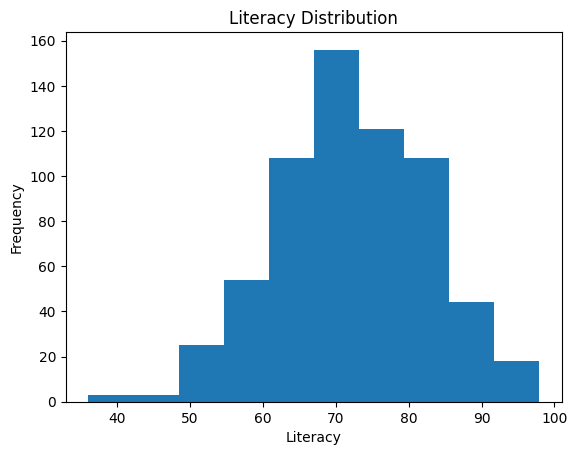


Graph 1 Insight:
Most districts fall in 60–85 range → Medium literacy dominates.


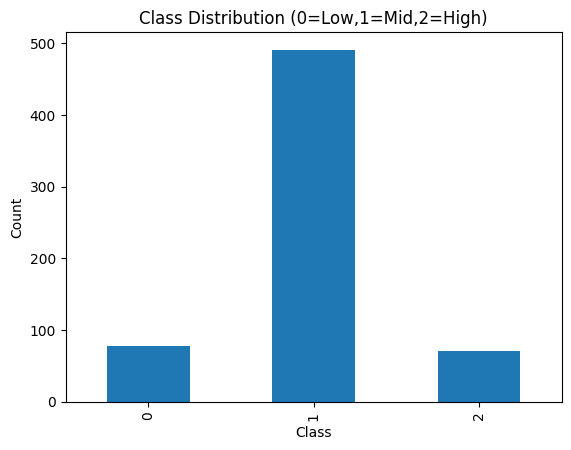


Graph 2 Insight:
Medium literacy districts are highest, Low are least.


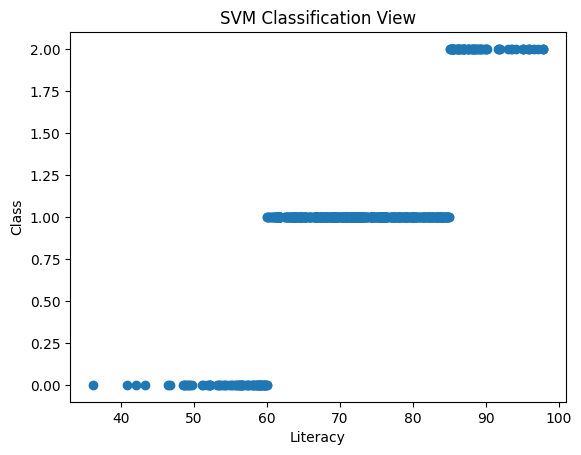


Graph 3 Insight:
Clear separation between classes shows SVM can classify effectively.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('Literacy Data 2011.csv')

# Drop unnecessary column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# -----------------------------
# Step 1: Create Classes
# -----------------------------
def categorize(lit):
    if lit < 60:
        return 0   # Low
    elif lit < 85:
        return 1   # Mid
    else:
        return 2   # High

df['Class'] = df['Literacy'].apply(categorize)

# -----------------------------
# Step 2: Train SVM Model
# -----------------------------
X = df[['Literacy']]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SVM Model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = model.score(X_test, y_test)
print("SVM Accuracy:", accuracy)

# -----------------------------
# Step 3: Evaluation
# -----------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Interpretation
print("\nModel Interpretation:")
print("SVM separates literacy into Low, Medium, and High classes using linear boundaries.")
print("High accuracy shows the data is well-separated based on literacy values.")

# -----------------------------
# Step 4: Visualization
# -----------------------------

# Graph 1: Histogram
plt.figure()
plt.hist(df['Literacy'])
plt.title("Literacy Distribution")
plt.xlabel("Literacy")
plt.ylabel("Frequency")
plt.show()

print("\nGraph 1 Insight:")
print("Most districts fall in 60–85 range → Medium literacy dominates.")

# Graph 2: Class Distribution
plt.figure()
df['Class'].value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution (0=Low,1=Mid,2=High)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("\nGraph 2 Insight:")
print("Medium literacy districts are highest, Low are least.")

# Graph 3: Scatter Plot
plt.figure()
plt.scatter(df['Literacy'], df['Class'])
plt.title("SVM Classification View")
plt.xlabel("Literacy")
plt.ylabel("Class")
plt.show()

print("\nGraph 3 Insight:")
print("Clear separation between classes shows SVM can classify effectively.")
